In [9]:


import pandas as pd
file_path = 'original data/The impact of artificial intelligence on society.csv'

try:
    df = pd.read_csv(file_path, encoding='latin-1')
    print(" تم تحميل البيانات بنجاح ")
except:
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
        print(" تم تحميل البيانات بنجاح (utf-8)")
    except Exception as e:
        print(f" خطأ في قراءة الملف: {e}")
        raise

print(f"تم تحميل {len(df)} صف و {len(df.columns)} عمود")


 تم تحميل البيانات بنجاح 
تم تحميل 205 صف و 20 عمود


In [10]:


import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df_original = df.copy()
print(" تم حفظ نسخة من البيانات الأصلية")

#  التنظيف
print("\n خطوة 3: تنظيف البيانات...")

# تصحيح Education
df['What is your education level?'] = df['What is your education level?'].replace({
    "Ön Bachelor's degree": "Associate degree"
})
print(" تم تصحيح Education")

# تصحيح Employment
df['What is your employment status?'] = df['What is your employment status?'].replace({
    'Emekliyim': 'Retired'
})
print(" تم تصحيح Employment Status")

# ملء Occupation
empty_count = df['What is your occupation? (optional)'].isna().sum()
print(f"عدد الصفوف الفاضية: {empty_count}")

for idx, row in df.iterrows():
    if pd.isna(row['What is your occupation? (optional)']):
        emp_status = row['What is your employment status?']

        if emp_status == 'Student':
            df.at[idx, 'What is your occupation? (optional)'] = 'Student'
        elif emp_status == 'Employed':
            df.at[idx, 'What is your occupation? (optional)'] = 'Not specified'
        elif emp_status == 'Unemployed':
            df.at[idx, 'What is your occupation? (optional)'] = 'Unemployed'
        elif emp_status == 'Retired':
            df.at[idx, 'What is your occupation? (optional)'] = 'Retired'

empty_after = df['What is your occupation? (optional)'].isna().sum()
print(f"عدد الفراغات بعد الملء: {empty_after}")
print("تم ملء Occupation")

# تنظيف المسافات
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()
print(" تم تنظيف المسافات")

# حفظ البيانات النظيفة
import os
os.makedirs('data', exist_ok=True)
df.to_csv('data/data_cleaned.csv', index=False, encoding='utf-8-sig')
print("\n تم حفظ: data/data_cleaned.csv")

#============ تحويل البيانات لمقاييس ===========
#  ساعات استخدام الأجهزة
device_hours_map = {
    'I never use it': 0,
    'Between 0 to 2 hours per day': 1,
    'Between 2 to 5 hours per day': 3.5,
    'Between 5 to 10 hours per day': 7.5,
    'More than 10 hours per day': 12
}
df['device_hours_score'] = df['How often do you use technological devices?'].map(device_hours_map)
print(" تم إنشاء: device_hours_score")

#  المعرفة الذاتية
knowledge_map = {
    'I have no knowledge': 0,
    "I've heard a little about it": 2.5,
    'I have basic knowledge': 5,
    'I have a good level of knowledge': 7.5,
    'I have an expert-level knowledge': 10
}
df['knowledge_score'] = df['How much knowledge do you have about artificial intelligence (AI) technologies?'].map(knowledge_map)
print(" تم إنشاء: knowledge_score")

# الثقة
trust_map = {
    "I don't trust it at all": 0,
    "I don't trust it": 2.5,
    "I'm undecided": 5,
    "I trust it": 7.5,
    "I fully trust it": 10
}
df['trust_score'] = df['Do you generally trust artificial intelligence (AI)?'].map(trust_map)
print(" تم إنشاء: trust_score (الثقة المباشرة)")

#  الفائدة/الضرر
beneficial_map = {
    'Definitely harmful': 0,
    'More harmful than beneficial': 2.5,
    'Both beneficial and harmful': 5,
    'More beneficial than harmful': 7.5,
    'Definitely beneficial': 10
}
df['beneficial_score'] = df['Do you think artificial intelligence (AI) will be generally beneficial or harmful to humanity?'].map(beneficial_map)
print(" تم إنشاء: beneficial_score")

#  استخدام AI
df['ai_usage_score'] = (df['Please rate how actively you use AI-powered products in your daily life on a scale from 1 to 5.'] / 5) * 10
print(" تم إنشاء: ai_usage_score")

#  الرغبة المستقبلية
future_map = {
    'Definitely, I would not like to': 0,
    'I would not like to': 2.5,
    "I'm undecided": 5,
    'I would like to': 7.5,
    'Definitely, I would like to': 10
}
df['future_intent_score'] = df['Would you like to use more AI products in the future?'].map(future_map)
print(" تم إنشاء: future_intent_score")

#  تهديد الحريات
threat_map = {
    'Strongly disagree': 0,
    'I disagree': 2.5,
    "I'm undecided": 5,
    'Agree': 7.5,
    'Strongly Agree': 10
}
df['threat_freedoms_score'] = df['I think artificial intelligence (AI) could threaten individual freedoms.'].map(threat_map)
print(" تم إنشاء: threat_freedoms_score")

# تهديد المهن
job_elim_map = {
    "Absolutely Can't handle it": 0,
    "Can't handle it": 2.5,
    'I have no idea': 5,
    'Removes': 7.5,
    'Definitely Removes': 10
}
df['job_elimination_score'] = df['Could artificial intelligence (AI) completely eliminate some professions?'].map(job_elim_map)
print(" تم إنشاء: job_elimination_score")

# تهديد الوظيفة الشخصية
personal_job_map = {
    "Definitely I don't think so": 0,
    "I don't think so": 2.5,
    "I'm undecided": 5,
    'Think': 7.5,
    'I definitely think': 10
}
df['personal_job_threat_score'] = df['Do you think your own job could be affected by artificial intelligence (AI)?'].map(personal_job_map)
print(" تم إنشاء: personal_job_threat_score")

#  القيود الأخلاقية
ethical_map = {
    'Strongly disagree': 0,
    'I disagree': 2.5,
    "I'm undecided": 5,
    'Agree': 7.5,
    'Strongly Agree': 10
}
df['ethical_constraints_score'] = df['Do you believe that artificial intelligence (AI) should be limited by ethical rules?'].map(ethical_map)
print(" تم إنشاء: ethical_constraints_score")

# الوعي الذاتي
consciousness_map = {
    "It certainly can't be": 0,
    "Can't": 2.5,
    "I'm undecided": 5,
    'Becomes': 7.5,
    'Definitely Becomes': 10
}
df['consciousness_score'] = df['Could artificial intelligence (AI) one day become conscious like humans?'].map(consciousness_map)
print(" تم إنشاء: consciousness_score")

# الأسئلة التقنية
df['q1_correct'] = (df['Which of the following do you think is NOT an artificial intelligence (AI) application?'] == 'WhatsApp').astype(int)
df['q2_correct'] = (df['Which of the following is a machine learning algorithm used in the field of artificial intelligence?'] == 'Linear regression').astype(int)
df['q3_correct'] = (df["The artificial intelligence application called 'ChatGPT' is an example of which type of AI system?"] == 'Natural language processing').astype(int)
print(" تم إنشاء: q1_correct, q2_correct, q3_correct")

# ============== الأعمدة المشتقة =============

#  الراحة مع التكنولوجيا
df['device_hours_normalized'] = (df['device_hours_score'] / 12) * 10
df['tech_comfort_level'] = df[['device_hours_normalized', 'ai_usage_score']].mean(axis=1)
print(" تم إنشاء: tech_comfort_level")

#  المعرفة الحقيقية نأخذ فقط تقييم اجابات الأسئلة التقنية لتحديد معدل المعرفة الحقيقية
df['ai_literacy_score'] = ((df['q1_correct'] + df['q2_correct'] + df['q3_correct']) / 3) * 10
print(" تم إنشاء: ai_literacy_score (بناءً على الأسئلة التقنية فقط)")

#  الثقة في الai
#  نأخذالأسئلةالتي تعكس الثقة
trust_items = [
    'trust_score',
    'beneficial_score',
    'future_intent_score'
]


for i, item in enumerate(trust_items, 1):
    print(f"     {i}. {item}")

# حساب المتوسط لأسئلة الثقة من أجل معرفة الثقة الشاملة في الai
df['trust_index'] = df[trust_items].mean(axis=1)

print("تم إنشاء: trust_index")
print(f"   المتوسط: {df['trust_index'].mean():.2f}/10")

#  معدل القلق
# الأسئلةالتي تعكس الشعور بالسلبية تجاه الذكاء الاصطناعي
anxiety_items = [
    'threat_freedoms_score',
    'job_elimination_score',
    'personal_job_threat_score',
    'consciousness_score'
]

for i, item in enumerate(anxiety_items, 1):
    print(f"     {i}. {item}")

# حساب المتوسط
df['anxiety_index'] = df[anxiety_items].mean(axis=1)

print(" تم إنشاء: anxiety_index")
print(f"   المتوسط: {df['anxiety_index'].mean():.2f}/10")

#  تحليل العلاقة بين الثقة والقلق

# حساب الارتباط
#correlation = df['trust_composite_index'].corr(df['ai_anxiety_index'])
#print(f"   معامل الارتباط: {correlation:.3f}")

#
#  متغيرات إضافية

# الفرق بين الثقة والقلق
df['trust_anxiety_gap'] = df['trust_index'] - df['anxiety_index']
print(" تم إنشاء: trust_anxiety_gap")
print(f"   المتوسط: {df['trust_anxiety_gap'].mean():.2f}")
print("   (إيجابي = الثقة أعلى من القلق، سالب = القلق أعلى من الثقة)")

# ب) التوازن بين الثقة والقلق
df['trust_anxiety_balance'] = (df['trust_index'] + (10 - df['anxiety_index'])) / 2
print(" تم إنشاء: trust_anxiety_balance")
print(f"   المتوسط: {df['trust_anxiety_balance'].mean():.2f}/10")
print("   (مقياس موحد: 0 = موقف سلبي جداً، 10 = موقف إيجابي جداً)")

# ج) تصنيف الموقف (4 فئات)
def categorize_attitude(row):
    """تصنيف الموقف حسب الثقة والقلق"""
    trust = row['trust_index']
    anxiety = row['anxiety_index']

    if pd.isna(trust) or pd.isna(anxiety):
        return 'Unknown'

    # عتبات التصنيف
    high_threshold = 6.0
    low_threshold = 4.0

    if trust >= high_threshold and anxiety < low_threshold:
        return 'Optimist'  # متفائل (ثقة عالية + قلق منخفض)
    elif trust >= high_threshold and anxiety >= high_threshold:
        return 'Cautious'  # حذر (ثقة عالية + قلق عالي)
    elif trust < low_threshold and anxiety < low_threshold:
        return 'Indifferent'  # لا مبالي (ثقة منخفضة + قلق منخفض)
    elif trust < low_threshold and anxiety >= high_threshold:
        return 'Resister'  # رافض (ثقة منخفضة + قلق عالي)
    else:
        return 'Moderate'  #معتدل

df['attitude_category'] = df.apply(categorize_attitude, axis=1)
print(" تم إنشاء: attitude_category")
print("   الفئات:")
attitude_counts = df['attitude_category'].value_counts()
for category, count in attitude_counts.items():
    pct = (count / len(df)) * 100
    print(f"   - {category}: {count} ({pct:.1f}%)")



#  معدل اللامبالاة وهو حساب معدل الاجابات غير المحددة والتي تدل على عدم الاهتمام في التكنلوجيا عموماً
ai_related_columns = [
    'How much knowledge do you have about artificial intelligence (AI) technologies?',
    'Do you generally trust artificial intelligence (AI)?',
    'Do you think artificial intelligence (AI) will be generally beneficial or harmful to humanity?',
    'Please rate how actively you use AI-powered products in your daily life on a scale from 1 to 5.',
    'Would you like to use more AI products in the future?',
    'I think artificial intelligence (AI) could threaten individual freedoms.',
    'Could artificial intelligence (AI) completely eliminate some professions?',
    'Do you think your own job could be affected by artificial intelligence (AI)?',
    'Do you believe that artificial intelligence (AI) should be limited by ethical rules?',
    'Could artificial intelligence (AI) one day become conscious like humans?',
    'Which of the following do you think is NOT an artificial intelligence (AI) application?',
    'Which of the following is a machine learning algorithm used in the field of artificial intelligence?',
    "The artificial intelligence application called 'ChatGPT' is an example of which type of AI system?"
]

indifference_keywords = ["I do not know", "I have no idea", "I have no knowledge"]

def calculate_indifference(row):
    count = 0
    total = 0
    for col in ai_related_columns:
        if col in df.columns:
            total += 1
            if pd.notna(row[col]):
                cell_value = str(row[col])
                if any(keyword in cell_value for keyword in indifference_keywords):
                    count += 1
    if total > 0:
        return (count / total) * 100
    else:
        return 0

df['indifference_rate'] = df.apply(calculate_indifference, axis=1)
print("    تم إنشاء: indifference_rate")

# الفجوة بين الثقة والمعرفة الذاتية
df['knowledge_confidence_gap'] = df['trust_score'] - df['knowledge_score']
print("   تم إنشاء: knowledge_confidence_gap")

# فجوة الوعي الذاتي
df['literacy_perception_gap'] = df['knowledge_score'] - df['ai_literacy_score']

def categorize_gap(gap):
    if pd.isna(gap):
        return 'Unknown'
    elif gap < -2:
        return 'Underconfident'
    elif -2 <= gap <= 2:
        return 'Realistic'
    elif 2 < gap <= 5:
        return 'Overconfident'
    else:
        return 'Dunning-Kruger'

df['self_awareness_category'] = df['literacy_perception_gap'].apply(categorize_gap)
print("    تم إنشاء: literacy_perception_gap")
print("   تم إنشاء: self_awareness_category")

# نقاط الاتساق

def calculate_consistency(row):
    contradictions = 0

    if pd.notna(row['trust_score']) and pd.notna(row['beneficial_score']):
        if row['trust_score'] >= 7 and row['beneficial_score'] <= 3:
            contradictions += 1

    if pd.notna(row['trust_score']) and pd.notna(row['beneficial_score']):
        if row['trust_score'] <= 3 and row['beneficial_score'] >= 7:
            contradictions += 1

    if pd.notna(row['beneficial_score']) and pd.notna(row['future_intent_score']):
        if row['beneficial_score'] <= 3 and row['future_intent_score'] >= 7:
            contradictions += 1

    if pd.notna(row['beneficial_score']) and pd.notna(row['future_intent_score']):
        if row['beneficial_score'] >= 7 and row['future_intent_score'] <= 3:
            contradictions += 1

    if pd.notna(row['knowledge_score']):
        total_correct = row['q1_correct'] + row['q2_correct'] + row['q3_correct']
        if row['knowledge_score'] >= 8 and total_correct <= 1:
            contradictions += 1

    if pd.notna(row['trust_score']) and pd.notna(row['anxiety_index']):
        if row['trust_score'] >= 7 and row['anxiety_index'] >= 7:
            contradictions += 1

    consistency_score = 10 - (contradictions * 1.5)
    return max(0, consistency_score)

df['response_consistency_score'] = df.apply(calculate_consistency, axis=1)
print("   تم إنشاء: response_consistency_score")


#  حفظ البيانات النهائية
df.to_csv('data/data_final_with_derived_columns.csv', index=False, encoding='utf-8-sig')
print(" تم حفظ الملف النهائي: data/data_final_with_derived_columns.csv")

#  ملخص البيانات النهائية

print(f"\n عدد الصفوف: {len(df)}")
print(f" عدد الأعمدة بعد الإضافة: {len(df.columns)}")

print("\n" + "="*80)


basic_derived = [
    'device_hours_score', 'knowledge_score', 'trust_score',
    'beneficial_score', 'ai_usage_score', 'future_intent_score',
    'threat_freedoms_score', 'job_elimination_score',
    'personal_job_threat_score', 'ethical_constraints_score',
    'consciousness_score', 'q1_correct', 'q2_correct', 'q3_correct'
]
for i, col in enumerate(basic_derived, 1):
    print(f"{i:2d}. {col}")

print("\n المتغيرات المشتقة المركبة:")
composite_derived = [
    'tech_comfort_level',
    'ai_literacy_score',
    'trust_index',
    'anxiety_index',
    'trust_anxiety_gap',
    'trust_anxiety_balance',
    'attitude_category',
    'indifference_rate',
    'knowledge_confidence_gap',
    'literacy_perception_gap',
    'self_awareness_category',
    'response_consistency_score',
    'device_hours_normalized'
]
for i, col in enumerate(composite_derived, 1):
    marker =" 🆕" if col in ['trust_index', 'trust_anxiety_gap',
                               'trust_anxiety_balance', 'attitude_category'] else ""
    print(f"{i:2d}. {col}{marker}")


# الثقة
print(f"   - trust_score :          {df['trust_score'].mean():.2f}/10 (±{df['trust_score'].std():.2f})")
print(f"   - trust_index : {df['trust_index'].mean():.2f}/10 (±{df['trust_index'].std():.2f})")
print(f"   - الفرق بين الثقة المباشرة والثقة الأعمق:    {(df['trust_score'] - df['trust_index']).mean():.2f}")

# القلق
print(f"   - anxiety_index:             {df['anxiety_index'].mean():.2f}/10 (±{df['anxiety_index'].std():.2f})")

# المعرفة
print(f"   - knowledge_score (متصورة):     {df['knowledge_score'].mean():.2f}/10 (±{df['knowledge_score'].std():.2f})")
print(f"   - ai_literacy_score (فعلية):    {df['ai_literacy_score'].mean():.2f}/10 (±{df['ai_literacy_score'].std():.2f})")
#الفجوات
print(f"   - knowledge_confidence_gap:     {df['knowledge_confidence_gap'].mean():.2f}")
print(f"   - literacy_perception_gap:      {df['literacy_perception_gap'].mean():.2f}")
print(f"   - trust_anxiety_gap:            {df['trust_anxiety_gap'].mean():.2f}")
#العلاقات
print(f"   - trust_composite × ai_anxiety: {df['trust_index'].corr(df['anxiety_index']):.3f}")
print(f"   - trust × knowledge:            {df['trust_score'].corr(df['knowledge_score']):.3f}")
print(f"   - trust × literacy:             {df['trust_score'].corr(df['ai_literacy_score']):.3f}")
#اللامبالاة
print(f"   - indifference_rate:            {df['indifference_rate'].mean():.1f}%")
#توزيع الفئات
print("\n توزيع فئات الوعي الذاتي:")
awareness_dist = df['self_awareness_category'].value_counts()
for category, count in awareness_dist.items():
    pct = (count / len(df)) * 100
    print(f"   - {category:15s}: {count:3d} ({pct:5.1f}%)")

print(f"\n توزيع فئات الموقف من AI:")
attitude_dist = df['attitude_category'].value_counts()
for category, count in attitude_dist.items():
    pct = (count / len(df)) * 100
    print(f"   - {category:15s}: {count:3d} ({pct:5.1f}%)")

print("=============== النهاية ================")

 تم حفظ نسخة من البيانات الأصلية

 خطوة 3: تنظيف البيانات...
 تم تصحيح Education
 تم تصحيح Employment Status
عدد الصفوف الفاضية: 60
عدد الفراغات بعد الملء: 0
تم ملء Occupation
 تم تنظيف المسافات

 تم حفظ: data/data_cleaned.csv
 تم إنشاء: device_hours_score
 تم إنشاء: knowledge_score
 تم إنشاء: trust_score (الثقة المباشرة)
 تم إنشاء: beneficial_score
 تم إنشاء: ai_usage_score
 تم إنشاء: future_intent_score
 تم إنشاء: threat_freedoms_score
 تم إنشاء: job_elimination_score
 تم إنشاء: personal_job_threat_score
 تم إنشاء: ethical_constraints_score
 تم إنشاء: consciousness_score
 تم إنشاء: q1_correct, q2_correct, q3_correct
 تم إنشاء: tech_comfort_level
 تم إنشاء: ai_literacy_score (بناءً على الأسئلة التقنية فقط)
     1. trust_score
     2. beneficial_score
     3. future_intent_score
تم إنشاء: trust_index
   المتوسط: 5.27/10
     1. threat_freedoms_score
     2. job_elimination_score
     3. personal_job_threat_score
     4. consciousness_score
 تم إنشاء: anxiety_index
   المتوسط: 5.78/10
 

 التحليل الوصفي للبيانات

 أولاً: الإحصائيات الوصفية الأساسية

 التوزيعات الديموغرافية:
--------------------------------------------------------------------------------

 العمر (What is your age range?):
الفئة                             العدد    النسبة%
--------------------------------------------------
18-24                                65      31.7%
45 years and older                   49      23.9%
Under 18 years old                   38      18.5%
35-44                                34      16.6%
25-34                                19       9.3%

 الجنس (What is your gender?):
الفئة                             العدد    النسبة%
--------------------------------------------------
Female                              114      55.6%
Male                                 91      44.4%

 المستوى التعليمي (What is your education level?):
الفئة                             العدد    النسبة%
--------------------------------------------------
Bachelor's degree                   101      49.3

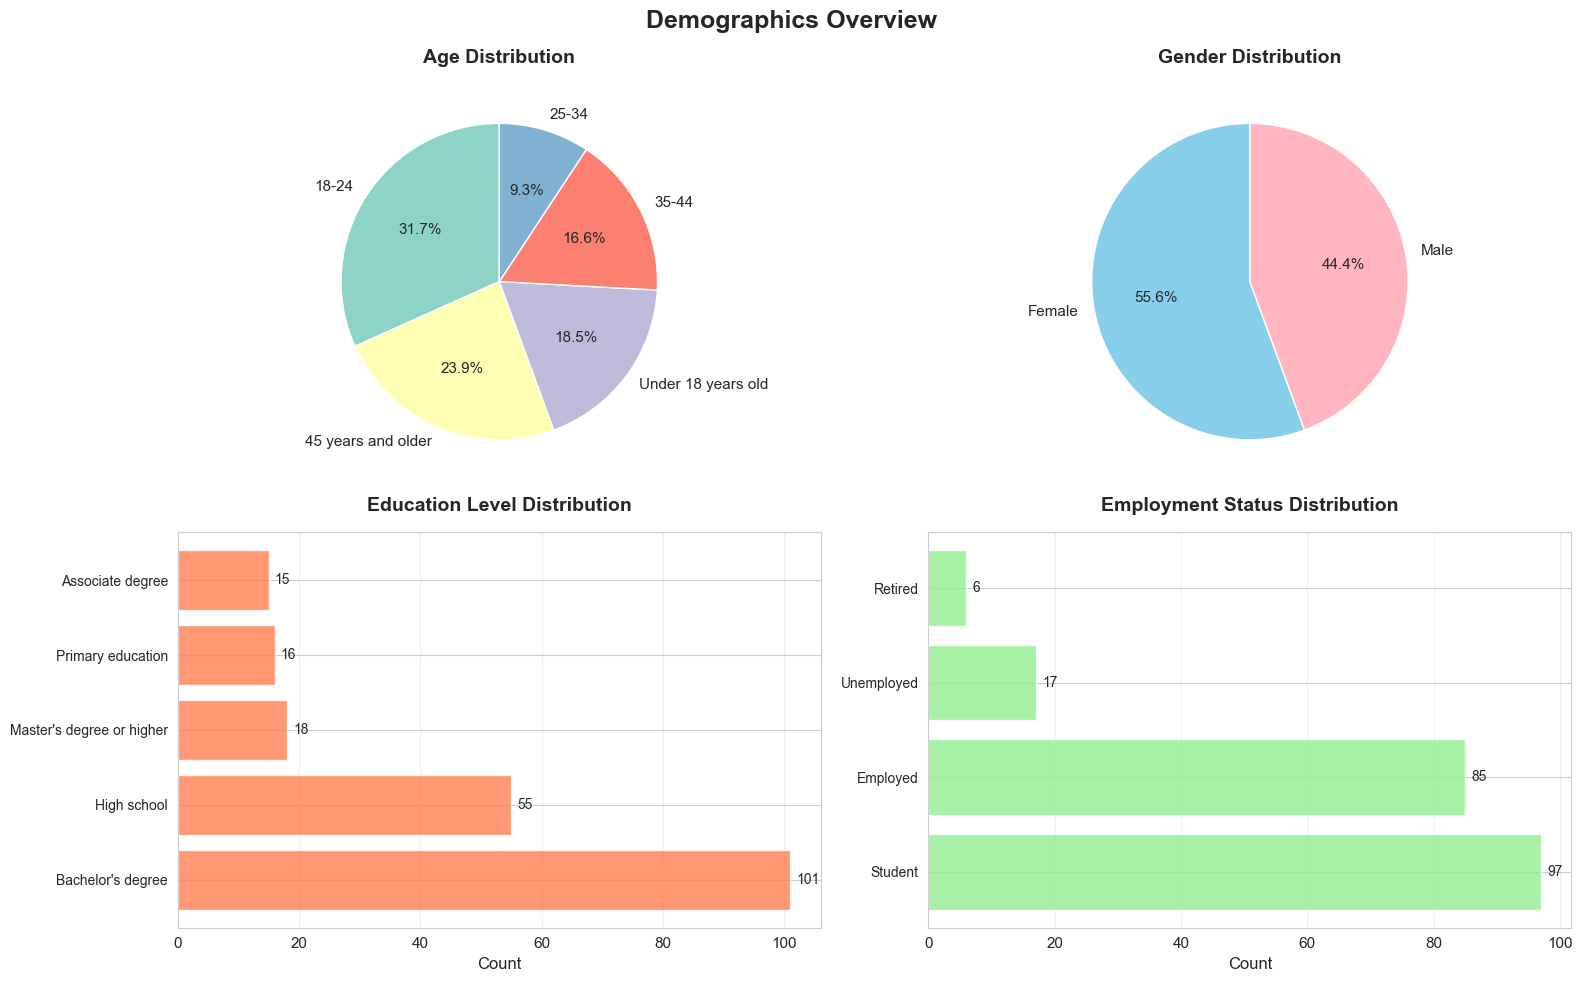

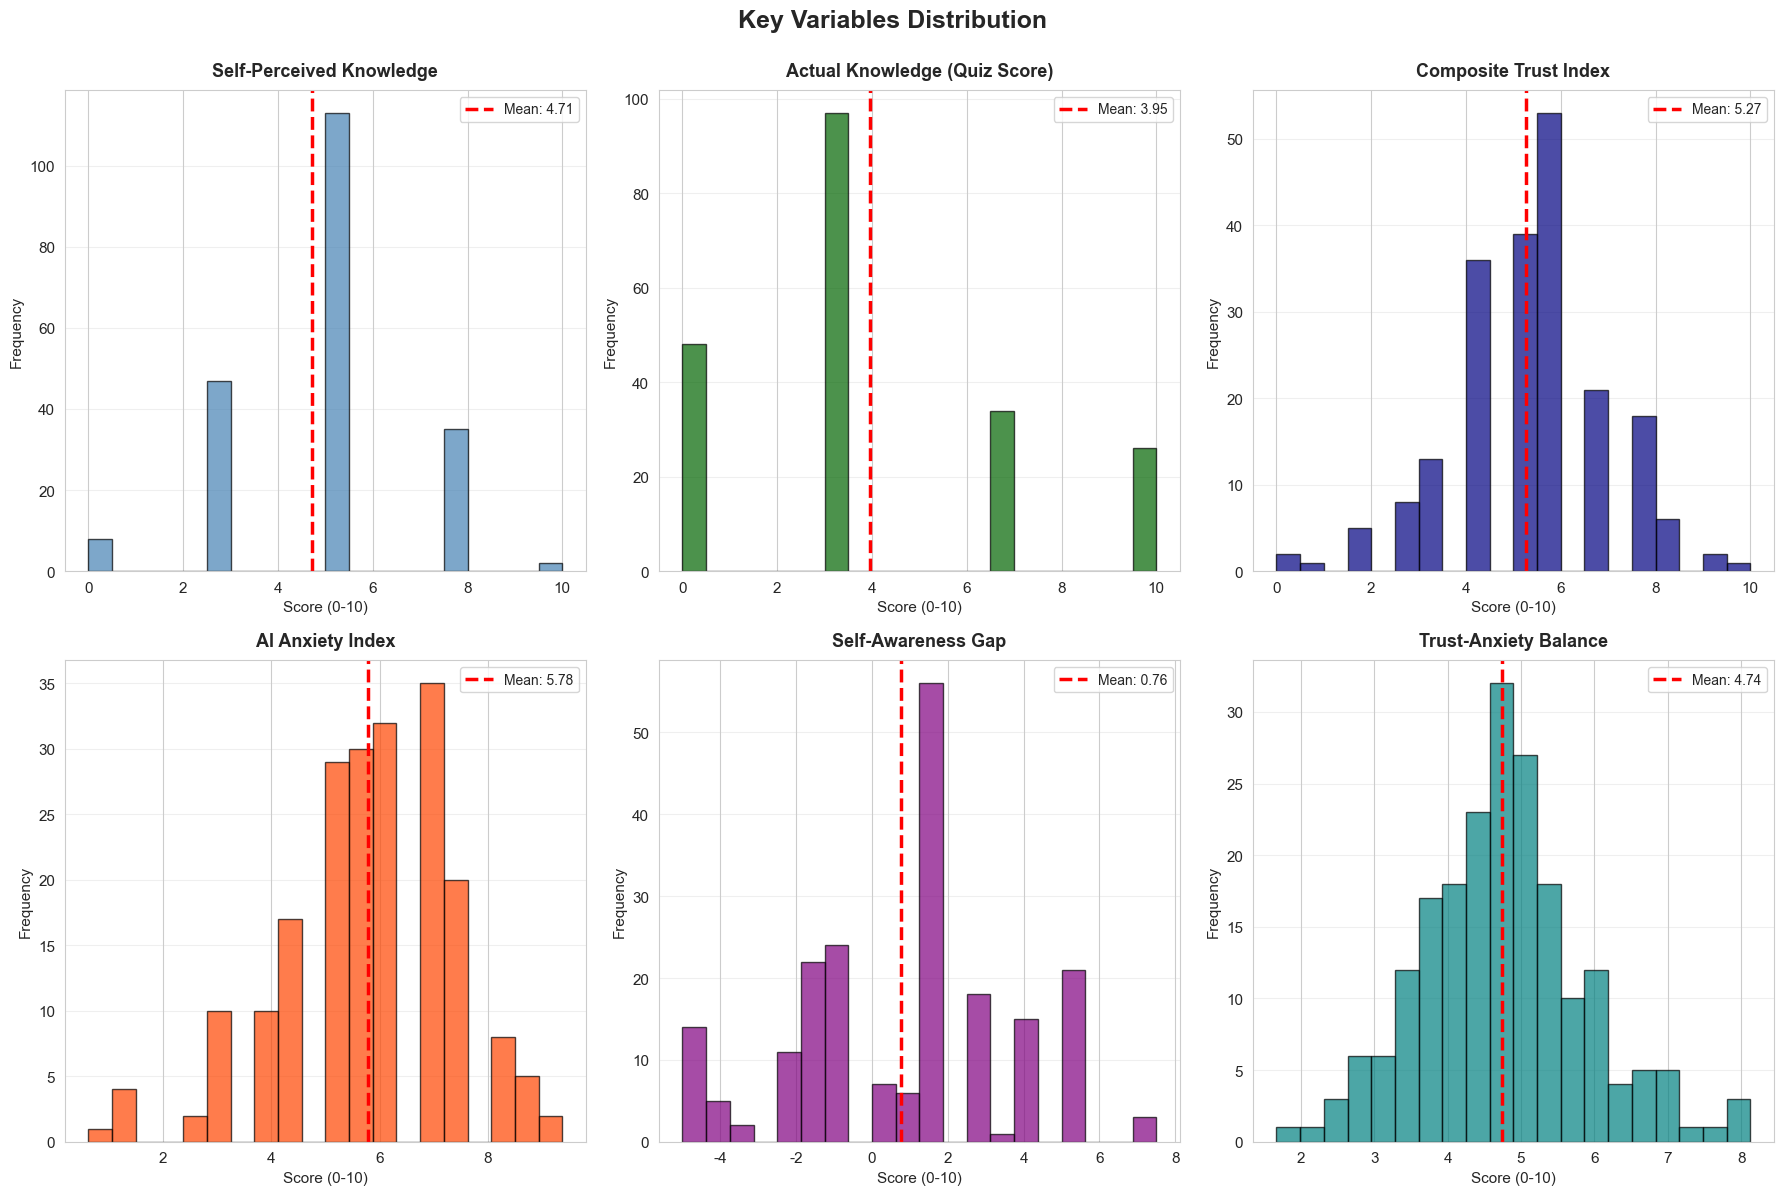

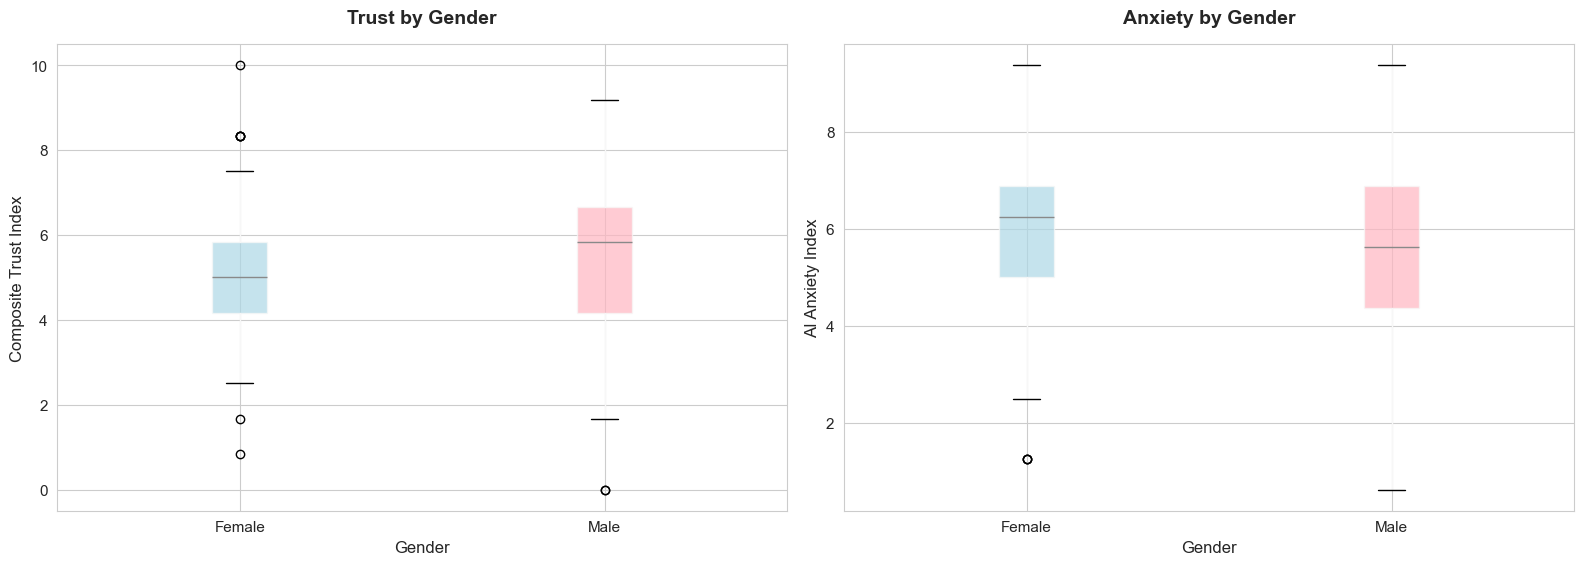

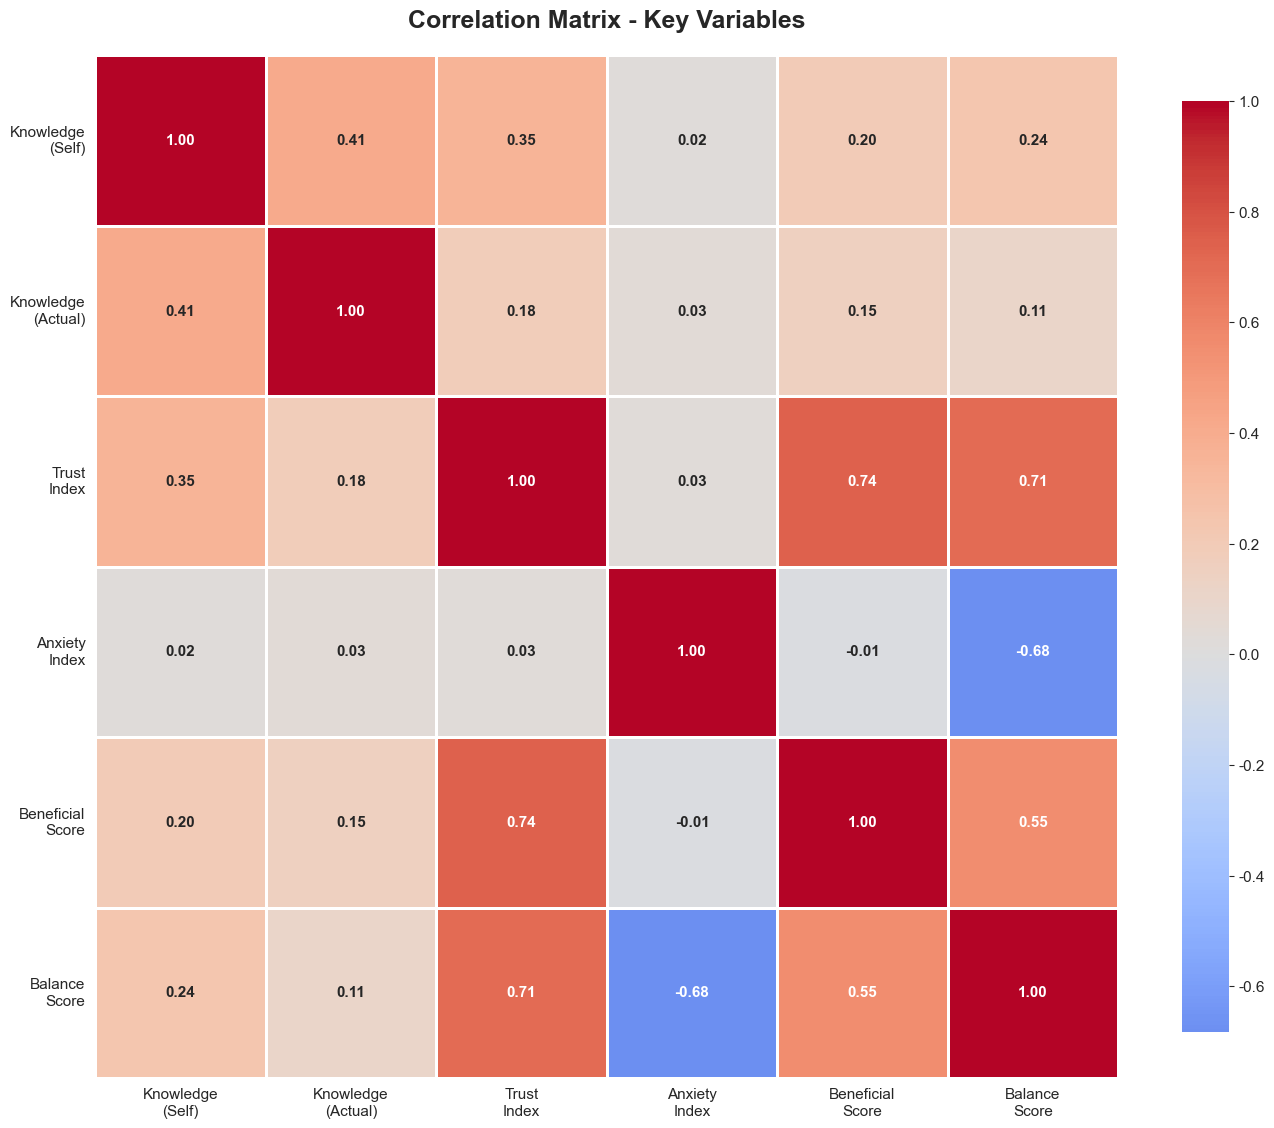


 أخيراً : الملخص النهائي

 أهم النتائج:
--------------------------------------------------------------------------------

1 الثقة العامة في AI:
   المتوسط: 5.27/10 (متوسطة)

 القلق العام من AI:
   المتوسط: 5.78/10 (متوسط)

 فجوة الوعي الذاتي:
   المتوسط: 0.76 (واقعي)

 الفروق بين الجنسين:
   الثقة - الذكور: 5.33, الإناث: 5.22
   الفرق: 0.11 نقطة
   النتيجة: لا يوجد فرق دال إحصائياً

 أهم الارتباطات:
   الثقة × القلق: r = 0.030
   المعرفة × الثقة: r = 0.350

   1. data/visualizations/01_demographics.png
   2. data/visualizations/02_key_variables.png
   3. data/visualizations/03_gender_comparison.png
   4. data/visualizations/04_correlation_matrix.png

======================= النهاية =======================


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import matplotlib.font_manager as fm

# البحث عن خطوط عربية متاحة في النظام
available_fonts = [f.name for f in fm.fontManager.ttflist]
arabic_fonts = ['Arabic Typesetting', 'Traditional Arabic', 'Simplified Arabic',
                'DejaVu Sans', 'Segoe UI', 'Arial Unicode MS', 'Tahoma']

# اختيار أول خط متاح يدعم العربي
selected_font = None
for font in arabic_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = selected_font
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'

#اغدادات لتحسين العرض
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.unicode_minus'] = False  # حل مشكلة علامة الناقص
plt.rcParams['figure.autolayout'] = True    # تنسيق تلقائي

sns.set_style("whitegrid")
sns.set_palette("husl")

print("="*90)
print(" التحليل الوصفي للبيانات")
print("="*90)
df = pd.read_csv('data/data_final_with_derived_columns.csv')

#  الإحصائيات الوصفية الأساسية
print("\n" + "="*90)
print(" أولاً: الإحصائيات الوصفية الأساسية")
print("="*90)

# المتغيرات الديموغرافية
print("\n التوزيعات الديموغرافية:")
print("-" * 80)

demographic_vars = {
    'What is your age range?': 'العمر',
    'What is your gender?': 'الجنس',
    'What is your education level?': 'المستوى التعليمي',
    'What is your employment status?': 'الحالة الوظيفية'
}

for col_name, ar_name in demographic_vars.items():
    print(f"\n {ar_name} ({col_name}):")
    counts = df[col_name].value_counts()
    total = len(df)

    print(f"{'الفئة':<30} {'العدد':>8} {'النسبة%':>10}")
    print("-" * 50)
    for category, count in counts.items():
        pct = (count / total) * 100
        print(f"{str(category):<30} {count:>8} {pct:>9.1f}%")

#  : المتغيرات الرئيسية (المقاييس)

print("\n" + "="*80)
print(" ثانياً : الإحصائيات الوصفية للمتغيرات الرئيسية")
print("="*80)

# نأخذ المتغيرات الأساسية للتحليل
key_variables = {
    'knowledge_score': 'المعرفة الذاتية المدركة',
    'ai_literacy_score': 'المعرفة الفعلية',
    'trust_score': 'الثقة المباشرة',
    'trust_index': 'الثقة الفعلية',
    'anxiety_index': 'مؤشر القلق',
    'beneficial_score': 'الفائدة/الضرر',
    'trust_anxiety_balance': 'التوازن',
    'literacy_perception_gap': 'فجوة الوعي الذاتي'
}

print("\n ملخص إحصائي وصفي")
print(f"\n{'المتغير':<35} {'المتوسط':>8} {'الوسيط':>8} {'الانحراف':>8} {'الحد الأدنى':>10} {'الحد الأقصى':>10}")
print("=" * 75)

for var, ar_name in key_variables.items():
    if var in df.columns:
        mean_val = df[var].mean()
        median_val = df[var].median()
        std_val = df[var].std()
        min_val = df[var].min()
        max_val = df[var].max()

        print(f"{ar_name:<35} {mean_val:>8.2f} {median_val:>8.2f} {std_val:>8.2f} {min_val:>10.2f} {max_val:>10.2f}")

# : التحليلات المقارنة

print("\n" + "="*80)
print(" ثالثاً : التحليلات المقارنة")
print("="*80)

# 3.1 الثقة حسب الجنس
print("\n متوسط الثقة حسب الجنس:")
trust_by_gender = df.groupby('What is your gender?')['trust_index'].agg([
    ('العدد', 'count'),
    ('المتوسط', 'mean'),
    ('الانحراف', 'std')
]).round(2)
print(trust_by_gender)

# اختبار
males = df[df['What is your gender?'] == 'Male']['trust_index'].dropna()
females = df[df['What is your gender?'] == 'Female']['trust_index'].dropna()
t_stat, p_value = stats.ttest_ind(males, females)
print(f"\nاختبار T-test:")
print(f"  t-statistic = {t_stat:.3f}")
print(f"  p-value = {p_value:.4f}")
if p_value < 0.05:
    print(f"   يوجد فرق دال إحصائياً (p < 0.05)")
else:
    print(f"   لا يوجد فرق دال إحصائياً (p ≥ 0.05)")

# 3.2 القلق حسب الفئة العمرية
print("\n" + "=" * 80)
print(" متوسط القلق حسب الفئة العمرية:")
anxiety_by_age = df.groupby('What is your age range?')['anxiety_index'].agg([
    ('العدد', 'count'),
    ('المتوسط', 'mean'),
    ('الانحراف', 'std')
]).round(2)
print(anxiety_by_age)

# القسم 4: مصفوفة الارتباطات
print("\n" + "="*80)
print(" رابعاً : مصفوفة الارتباطات")
print("="*80)

corr_vars = [
    'knowledge_score',
    'ai_literacy_score',
    'trust_index',
    'anxiety_index',
    'beneficial_score',
    'trust_anxiety_balance'
]

print("\n مصفوفة الارتباط (Pearson):")
correlation_matrix = df[corr_vars].corr().round(3)
print(correlation_matrix)

print("\n الارتباطات القوية (|r| > 0.5):")
print(f"{'المتغير 1':<30} {'المتغير 2':<30} {'الارتباط':>12}")
print("-" * 75)

for i in range(len(corr_vars)):
    for j in range(i+1, len(corr_vars)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            var1 = key_variables.get(corr_vars[i], corr_vars[i])
            var2 = key_variables.get(corr_vars[j], corr_vars[j])
            print(f"{var1:<30} {var2:<30} {corr_val:>12.3f}")


# خامساً : الرسوم البيانية
print("\n" + "="*80)
print(" خامساً: الرسوم البيانية الأساسية")

# : التوزيعات الديموغرافية
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Demographics Overview', fontsize=18, fontweight='bold', y=0.98)

# العمر
ax1 = plt.subplot(2, 2, 1)
age_counts = df['What is your age range?'].value_counts()
colors_age = plt.cm.Set3(range(len(age_counts)))
wedges, texts, autotexts = ax1.pie(age_counts.values, labels=age_counts.index,
                                     autopct='%1.1f%%', startangle=90, colors=colors_age,
                                     textprops={'fontsize': 11})
ax1.set_title('Age Distribution', fontsize=14, fontweight='bold', pad=15)

# الجنس
ax2 = plt.subplot(2, 2, 2)
gender_counts = df['What is your gender?'].value_counts()
colors_gender = ['#87CEEB', '#FFB6C1']
wedges2, texts2, autotexts2 = ax2.pie(gender_counts.values, labels=gender_counts.index,
                                        autopct='%1.1f%%', startangle=90, colors=colors_gender,
                                        textprops={'fontsize': 11})
ax2.set_title('Gender Distribution', fontsize=14, fontweight='bold', pad=15)

# التعليم
ax3 = plt.subplot(2, 2, 3)
education_counts = df['What is your education level?'].value_counts()
bars1 = ax3.barh(range(len(education_counts)), education_counts.values, color='coral', alpha=0.8)
ax3.set_yticks(range(len(education_counts)))
ax3.set_yticklabels(education_counts.index, fontsize=10)
ax3.set_xlabel('Count', fontsize=12)
ax3.set_title('Education Level Distribution', fontsize=14, fontweight='bold', pad=15)
ax3.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax3.text(width + 1, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             ha='left', va='center', fontsize=10)

# الوظيفة
ax4 = plt.subplot(2, 2, 4)
employment_counts = df['What is your employment status?'].value_counts()
bars2 = ax4.barh(range(len(employment_counts)), employment_counts.values, color='lightgreen', alpha=0.8)
ax4.set_yticks(range(len(employment_counts)))
ax4.set_yticklabels(employment_counts.index, fontsize=10)
ax4.set_xlabel('Count', fontsize=12)
ax4.set_title('Employment Status Distribution', fontsize=14, fontweight='bold', pad=15)
ax4.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax4.text(width + 1, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             ha='left', va='center', fontsize=10)

plt.tight_layout()
os.makedirs('data/visualizations', exist_ok=True)
plt.savefig('data/visualizations/01_demographics.png', dpi=300, bbox_inches='tight')
plt.show()

# : المتغيرات الرئيسية

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Key Variables Distribution', fontsize=18, fontweight='bold', y=0.995)

variables_to_plot = [
    ('knowledge_score', 'Self-Perceived Knowledge', 'steelblue'),
    ('ai_literacy_score', 'Actual Knowledge (Quiz Score)', 'darkgreen'),
    ('trust_index', 'Composite Trust Index', 'navy'),
    ('anxiety_index', 'AI Anxiety Index', 'orangered'),
    ('literacy_perception_gap', 'Self-Awareness Gap', 'purple'),
    ('trust_anxiety_balance', 'Trust-Anxiety Balance', 'teal')
]

for idx, (var, title, color) in enumerate(variables_to_plot):
    ax = axes[idx // 3, idx % 3]
    data = df[var].dropna()

    ax.hist(data, bins=20, edgecolor='black', alpha=0.7, color=color)
    ax.set_xlabel('Score (0-10)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

    mean_val = data.mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2.5,
               label=f'Mean: {mean_val:.2f}')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/visualizations/02_key_variables.png', dpi=300, bbox_inches='tight')
plt.show()

# : مقارنة الثقة والقلق حسب الجنس

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Trust & Anxiety by Gender', fontsize=18, fontweight='bold', y=0.98)

# Boxplot للثقة
bp1 = df.boxplot(column='trust_index', by='What is your gender?',
                  ax=axes[0], patch_artist=True, return_type='dict')
axes[0].set_title('Trust by Gender', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Composite Trust Index', fontsize=12)
axes[0].get_figure().suptitle('')

# تلوين الـ boxes
for patch, color in zip(bp1['trust_index']['boxes'], ['lightblue', 'lightpink']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Boxplot للقلق
bp2 = df.boxplot(column='anxiety_index', by='What is your gender?',
                  ax=axes[1], patch_artist=True, return_type='dict')
axes[1].set_title('Anxiety by Gender', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('AI Anxiety Index', fontsize=12)
axes[1].get_figure().suptitle('')

# تلوين الـ boxes
for patch, color in zip(bp2['anxiety_index']['boxes'], ['lightblue', 'lightpink']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.tight_layout()
plt.savefig('data/visualizations/03_gender_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# : مصفوفة الارتباطات
plt.figure(figsize=(14, 12))

# استخدام أسماء أقصر للمحاور
short_labels = {
    'knowledge_score': 'Knowledge\n(Self)',
    'ai_literacy_score': 'Knowledge\n(Actual)',
    'trust_index': 'Trust\nIndex',
    'anxiety_index': 'Anxiety\nIndex',
    'beneficial_score': 'Beneficial\nScore',
    'trust_anxiety_balance': 'Balance\nScore'
}

# إنشاء مصفوفة مع الأسماء القصيرة
correlation_renamed = correlation_matrix.rename(columns=short_labels, index=short_labels)

# رسم الـ heatmap
sns.heatmap(correlation_renamed, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            annot_kws={'fontsize': 11, 'weight': 'bold'})

plt.title('Correlation Matrix - Key Variables',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=0, ha='center', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('data/visualizations/04_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# : الملخص النهائي
# ============================================
print("\n" + "="*80)
print(" أخيراً : الملخص النهائي")
print("="*80)

print("\n أهم النتائج:")
print("-" * 80)

# 1. الثقة العامة
avg_trust = df['trust_index'].mean()
trust_interpretation = "عالية" if avg_trust >= 7 else ("متوسطة" if avg_trust >= 5 else "منخفضة")
print(f"\n1 الثقة العامة في AI:")
print(f"   المتوسط: {avg_trust:.2f}/10 ({trust_interpretation})")

# 2. القلق العام
avg_anxiety = df['anxiety_index'].mean()
anxiety_interpretation = "عالي" if avg_anxiety >= 7 else ("متوسط" if avg_anxiety >= 5 else "منخفض")
print(f"\n القلق العام من AI:")
print(f"   المتوسط: {avg_anxiety:.2f}/10 ({anxiety_interpretation})")

# 3. فجوة المعرفة
avg_gap = df['literacy_perception_gap'].mean()
gap_interpretation = "مبالغة" if avg_gap > 2 else ("واقعي" if abs(avg_gap) <= 2 else "متواضع")
print(f"\n فجوة الوعي الذاتي:")
print(f"   المتوسط: {avg_gap:.2f} ({gap_interpretation})")

# 4. الفروق بين الجنسين
print(f"\n الفروق بين الجنسين:")
male_trust = df[df['What is your gender?'] == 'Male']['trust_index'].mean()
female_trust = df[df['What is your gender?'] == 'Female']['trust_index'].mean()
print(f"   الثقة - الذكور: {male_trust:.2f}, الإناث: {female_trust:.2f}")
print(f"   الفرق: {abs(male_trust - female_trust):.2f} نقطة")
if p_value < 0.05:
    print(f"   النتيجة: يوجد فرق دال إحصائياً ")
else:
    print(f"   النتيجة: لا يوجد فرق دال إحصائياً")

# 5. أهم الارتباطات
print(f"\n أهم الارتباطات:")
corr_trust_anxiety = df['trust_index'].corr(df['anxiety_index'])
corr_knowledge_trust = df['knowledge_score'].corr(df['trust_index'])
print(f"   الثقة × القلق: r = {corr_trust_anxiety:.3f}")
print(f"   المعرفة × الثقة: r = {corr_knowledge_trust:.3f}")

print("\n" + "="*80)

saved_files = [
    'data/visualizations/01_demographics.png',
    'data/visualizations/02_key_variables.png',
    'data/visualizations/03_gender_comparison.png',
    'data/visualizations/04_correlation_matrix.png'
]
for i, file in enumerate(saved_files, 1):
    print(f"   {i}. {file}")

print("\n======================= النهاية =======================")


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Arial'
sns.set_palette("husl")

print("="*80)
print(" التحليل التقاطعي لثلاثة متغيرات")
print("="*80)

df = pd.read_csv('data/data_final_with_derived_columns.csv')
print(f"\n تم تحميل {len(df)} مشارك")

print("\n" + "="*80)
print(": التصنيفات (Categorization)")
print("="*80)

def categorize_literacy(score):
    if pd.isna(score):
        return 'Unknown'
    elif score < 4:
        return 'Low'
    elif score < 7:
        return 'Medium'
    else:
        return 'High'

df['literacy_category'] = df['ai_literacy_score'].apply(categorize_literacy)
print("\n تم تصنيف المعرفة الفعلية: Low / Medium / High")

def categorize_age(age_range):
    if pd.isna(age_range):
        return 'Unknown'
    elif 'Under 18' in str(age_range) or '18-24' in str(age_range):
        return 'Young'
    elif '25-34' in str(age_range) or '35-44' in str(age_range):
        return 'Middle'
    else:
        return 'Old'

df['age_category'] = df['What is your age range?'].apply(categorize_age)
print("تم تصنيف العمر: Young / Middle / Old")

def categorize_trust(score):
    if pd.isna(score):
        return 'Unknown'
    elif score < 4:
        return 'Low'
    elif score < 7:
        return 'Medium'
    else:
        return 'High'

df['trust_category'] = df['trust_score'].apply(categorize_trust)
print(" تم تصنيف الثقة: Low / Medium / High")

df['gender'] = df['What is your gender?']

print("\n" + "="*60)
print(" أولاً: دراسة العلاقة بين المعرفة والثقة والجندر ")
print("="*60)
print("\n السؤال: هل تأثير المعرفة على الثقة يختلف بين الجنسين؟")

analysis1 = df.groupby(['gender', 'literacy_category'])['trust_score'].agg([
    ('العدد', 'count'),
    ('المتوسط', 'mean'),
    ('الانحراف', 'std')
]).round(2)

print("\n النتائج:")
print("\nالجنس    المعرفة     العدد    متوسط الثقة    الانحراف")

for (gender, literacy), row in analysis1.iterrows():
    if literacy != 'Unknown' and not pd.isna(row['المتوسط']):
        print(f"{gender:8s} {literacy:10s} {row['العدد']:6.0f}    {row['المتوسط']:8.2f}       {row['الانحراف']:6.2f}")

print("\n تحليل التفاعل (Interaction Effect):")

try:
    male_low = df[(df['gender'] == 'Male') & (df['literacy_category'] == 'Low')]['trust_score'].mean()
    male_high = df[(df['gender'] == 'Male') & (df['literacy_category'] == 'High')]['trust_score'].mean()
    female_low = df[(df['gender'] == 'Female') & (df['literacy_category'] == 'Low')]['trust_score'].mean()
    female_high = df[(df['gender'] == 'Female') & (df['literacy_category'] == 'High')]['trust_score'].mean()

    male_effect = male_high - male_low
    female_effect = female_high - female_low

    print(f"\n تأثير المعرفة على الرجال: {male_effect:+.2f} نقطة")
    print(f"  (من {male_low:.2f} عند معرفة منخفضة الى {male_high:.2f} عند معرفة عالية)")

    print(f"\n تأثير المعرفة على النساء: {female_effect:+.2f} نقطة")
    print(f"  (من {female_low:.2f} عند معرفة منخفضة الى {female_high:.2f} عند معرفة عالية)")

    if abs(male_effect - female_effect) > 0.5:
        print(f"\n يوجد ارتباط: حيث المعرفة تؤثر بشكل مختلف حسب الجنس")
        if female_effect > male_effect:
            print(f"    المعرفة أكثر تأثيراً على النساء ({female_effect:.2f} vs {male_effect:.2f})")
        else:
            print(f"   المعرفة أكثر تأثيراً على الرجال ({male_effect:.2f} vs {female_effect:.2f})")
    else:
        print(f"\n لا يوجد ارتباط واضح (التأثير متشابه للجنسين)")
except:
    print("\n لا توجد بيانات كافية لتحليل التفاعل")

print("\n" + "="*80)
print(" ثانياً :دراسة العلاقة بين القلقق والعمر والمعرفة الفعلية")
print("="*80)
print("\n السؤال: هل المعرفة تقلل القلق؟ وهل هذا يختلف حسب العمر؟")

analysis2 = df.groupby(['age_category', 'literacy_category'])['anxiety_index'].agg([
    ('العدد', 'count'),
    ('المتوسط', 'mean'),
    ('الانحراف', 'std')
]).round(2)

print("\n النتائج:")
print("\nالعمر     المعرفة     العدد    متوسط القلق    الانحراف")

for (age, literacy), row in analysis2.iterrows():
    if literacy != 'Unknown' and age != 'Unknown' and not pd.isna(row['المتوسط']):
        print(f"{age:10s} {literacy:10s} {row['العدد']:6.0f}    {row['المتوسط']:8.2f}       {row['الانحراف']:6.2f}")

print("\n تحليل التفاعل:")

for age_group in ['Young', 'Middle', 'Old']:
    try:
        low_anxiety = df[(df['age_category'] == age_group) &
                        (df['literacy_category'] == 'Low')]['anxiety_index'].mean()
        high_anxiety = df[(df['age_category'] == age_group) &
                         (df['literacy_category'] == 'High')]['anxiety_index'].mean()

        effect = high_anxiety - low_anxiety

        age_label = {'Young': 'الشباب', 'Middle': 'متوسطي العمر', 'Old': 'كبار السن'}
        print(f"\n {age_label[age_group]}: تأثير المعرفة = {effect:+.2f}")

        if effect < -0.5:
            print(f"   المعرفة تخفض القلق (من {low_anxiety:.2f} الى {high_anxiety:.2f})")
        elif effect > 0.5:
            print(f"  المعرفة تزيد القلق (من {low_anxiety:.2f} الى {high_anxiety:.2f})")
        else:
            print(f"  المعرفة لا تؤثر كثيراً على القلق")
    except:
        pass

print("\n" + "="*80)
print(" ثالثاً: دراسة العلاقة بين متغير فجوة الوعي الذاتي والجندروالعمر")
print("="*80)
print("\n السؤال: أي الفئات تبالغ في معرفتها أكثر ؟")

analysis3 = df.groupby(['gender', 'age_category'])['literacy_perception_gap'].agg([
    ('العدد', 'count'),
    ('المتوسط', 'mean'),
    ('الانحراف', 'std')
]).round(2)

print("\n النتائج (الفجوة: موجب = مبالغة، سالب = تواضع):")
print("\nالجنس    العمر        العدد    متوسط الفجوة    الانحراف    التصنيف")

for (gender, age), row in analysis3.iterrows():
    if age != 'Unknown' and not pd.isna(row['المتوسط']):
        gap = row['المتوسط']
        if gap > 2:
            indicator = "Overconfident"
        elif abs(gap) <= 2:
            indicator = "Realistic"
        else:
            indicator = "Underconfident"
        print(f"{gender:8s} {age:12s} {row['العدد']:6.0f}    {gap:8.2f}       {row['الانحراف']:6.2f}    {indicator}")

print("\n تفسير الفجوات:")
print("  فجوة > +2: واهم حيث لديه مبالغة بثقته بنفسه ")
print("   فجوة -2 إلى +2: واع بذاته")
print("  فجوة < -2: غير واثق بنفسه ")

max_gap_group = analysis3['المتوسط'].idxmax()
max_gap_value = analysis3['المتوسط'].max()

print(f"\n الفئة الأكثر مبالغة: {max_gap_group[0]} - {max_gap_group[1]}")
print(f"   فجوة = +{max_gap_value:.2f} (يعطون أنفسهم علامات أعلى بـ {max_gap_value:.1f} نقطة من أدائهم)")

print("\n" + "="*80)
print(" رابعاً: دراسة العلاقة بين متغير التوازن الكلي والتعليم والحالة الوظيفية")
print("="*80)
print("\n السؤال: هل تأثير التعليم يختلف حسب السياق الوظيفي؟")

def simplify_employment(emp):
    if pd.isna(emp):
        return 'Unknown'
    elif 'Student' in str(emp):
        return 'Student'
    elif 'Employed' in str(emp):
        return 'Employed'
    elif 'Unemployed' in str(emp):
        return 'Unemployed'
    else:
        return 'Other'

df['employment_simple'] = df['What is your employment status?'].apply(simplify_employment)

def simplify_education(edu):
    if pd.isna(edu):
        return 'Unknown'
    elif 'Primary' in str(edu) or 'High school' in str(edu):
        return 'Secondary or Less'
    elif 'Bachelor' in str(edu) or 'Associate' in str(edu):
        return 'Bachelor'
    else:
        return 'Postgraduate'

df['education_simple'] = df['What is your education level?'].apply(simplify_education)

analysis4 = df.groupby(['employment_simple', 'education_simple'])['trust_anxiety_balance'].agg([
    ('العدد', 'count'),
    ('المتوسط', 'mean'),
    ('الانحراف', 'std')
]).round(2)

print("\n النتائج:")
print("\nالوظيفة      التعليم              العدد    متوسط التوازن    الانحراف    التقييم")
print("-" * 85)

for (emp, edu), row in analysis4.iterrows():
    if edu != 'Unknown' and emp != 'Unknown' and row['العدد'] >= 3:
        balance = row['المتوسط']
        if balance > 6:
            mood = "Positive"
        elif balance > 4:
            mood = "Neutral"
        else:
            mood = "Negative"
        print(f"{emp:12s} {edu:20s} {row['العدد']:6.0f}    {balance:8.2f}       {row['الانحراف']:6.2f}    {mood}")

print("\n تحليل التفاعل:")

for emp_group in ['Student', 'Employed', 'Unemployed']:
    try:
        secondary = df[(df['employment_simple'] == emp_group) &
                      (df['education_simple'] == 'Secondary or Less')]['trust_anxiety_balance'].mean()
        bachelor = df[(df['employment_simple'] == emp_group) &
                     (df['education_simple'] == 'Bachelor')]['trust_anxiety_balance'].mean()

        effect = bachelor - secondary

        emp_labels = {
            'Student': 'الطلاب',
            'Employed': 'الموظفين',
            'Unemployed': 'العاطلين'
        }

        print(f"\n {emp_labels[emp_group]}: تأثير التعليم الجامعي = {effect:+.2f}")

        if effect > 1:
            print(f"  التعليم الجامعي يحسن الموقف من الذكاء الاصطناعي")
        elif effect > 0:
            print(f"   التعليم الجامعي يحسن الموقف قليلاً")
        else:
            print(f"التعليم الجامعي لا يحسن الموقف أو ربما يجعله أسوأ")
    except:
        pass

print("\nحفظ النتائج...")

analysis1.to_csv('data/analysis1_trust_knowledge_gender.csv', encoding='utf-8-sig')
analysis2.to_csv('data/analysis2_anxiety_age_knowledge.csv', encoding='utf-8-sig')
analysis3.to_csv('data/analysis3_gap_gender_age.csv', encoding='utf-8-sig')
analysis4.to_csv('data/analysis4_balance_education_employment.csv', encoding='utf-8-sig')

print("\n"+"="*80)

 التحليل التقاطعي لثلاثة متغيرات

 تم تحميل 205 مشارك

: التصنيفات (Categorization)

 تم تصنيف المعرفة الفعلية: Low / Medium / High
تم تصنيف العمر: Young / Middle / Old
 تم تصنيف الثقة: Low / Medium / High

 أولاً: دراسة العلاقة بين المعرفة والثقة والجندر 

 السؤال: هل تأثير المعرفة على الثقة يختلف بين الجنسين؟

 النتائج:

الجنس    المعرفة     العدد    متوسط الثقة    الانحراف
Female   High            9        6.11         1.82
Female   Low            90        4.92         2.10
Female   Medium         15        4.67         1.86
Male     High           17        5.59         2.26
Male     Low            55        4.59         2.54
Male     Medium         19        5.26         2.34

 تحليل التفاعل (Interaction Effect):

 تأثير المعرفة على الرجال: +1.00 نقطة
  (من 4.59 عند معرفة منخفضة الى 5.59 عند معرفة عالية)

 تأثير المعرفة على النساء: +1.19 نقطة
  (من 4.92 عند معرفة منخفضة الى 6.11 عند معرفة عالية)

 لا يوجد ارتباط واضح (التأثير متشابه للجنسين)

 ثانياً :دراسة العلاقة بين القلقق وال